# 05 ACG-MAC and ablation experiments

**Scientific rationale.** A graph represents connectivity, a physical approximation supplies reference outputs, and observed/missing/age channels describe telemetry quality. ACG-MAC learns residual voltage and log-loss corrections, with auxiliary feasibility classification.

For features \(X\), adjacency \(A\), and valid-node mask \(m\), propagation uses \(\hat A=D^{-1/2}(A+I)D^{-1/2}\). Reliability \(r_i=\sigma(g(o_i,a_i))m_i\) weights mean pooling; max pooling remains unweighted. Pooled features and standardized descriptors enter the fusion MLP. Outputs are \(\widehat V_{\min}=V_{\mathrm{proxy}}+\Delta V\), \(\widehat L=\max(0,\exp(\log(1+L_{\mathrm{proxy}})+\Delta\ell)-1)\), and \(\widehat p=\sigma(z)\). Training combines scaled squared regression error and 0.18 times binary cross-entropy.

**Configuration.** The full model uses width 56, two graph propagations, learned reliability pooling, physical residual outputs, multitask classification and simple_fusion=True. The optional adaptive context gate is inactive. Reliability weights operate at pooling, not on each edge message. Ablations evaluate changes to individual components.

**Training path.** Train-only standardization; selection-only early stopping; five fixed seeds. **Inference path.** Observed telemetry and topology → proxies and graph features → five member predictions → mean outcome. Candidate ranking later receives a separate exact numerical feasibility filter.

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
assert (PROJECT / "src" / "models.py").is_file()
sys.path.insert(0, str(PROJECT))
from src.notebook_tools import configure_style, show_table, save_figure
from src.protocol import SEED, SEEDS, FULL_CONFIG, TRAINING, MODEL_ORDER

configure_style()
rng = np.random.default_rng(SEED)
FIGURES = PROJECT / "figures"
TABLES = PROJECT / "artifacts" / "generated" / "tables"
RESULTS = PROJECT / "artifacts" / "generated" / "results"
MODELS = PROJECT / "artifacts" / "generated" / "models"
for directory in (FIGURES, TABLES, RESULTS, MODELS):
    directory.mkdir(parents=True, exist_ok=True)


from src.models import DatasetBundle, load_bundle, split_indices, predict_graph_model
from src.protocol import (
    regression_metrics,
    probability_metrics,
    fit_tabular,
    predict_tabular,
    train_graph,
    save_graph,
    inner_group_selection,
    measure_resources,
    cluster_bootstrap,
    holm_adjust,
    calibrate_probability,
)

bundle = load_bundle(PROJECT / "dataset" / "processed")
metadata = bundle.metadata
indices = split_indices(bundle)
all_indices = np.arange(len(metadata))
valid_test = indices["test"][metadata.iloc[indices["test"]].converged.to_numpy() == 1]
fold_manifest = pd.read_csv(PROJECT / "dataset" / "processed" / "topology_folds.csv")
fold_id = fold_manifest.set_index("sample_id").loc[metadata.sample_id, "fold"].to_numpy()


def prediction_path(name: str) -> Path:
    """Use the same unambiguous model identifier throughout the study."""
    return RESULTS / (name.replace(" ", "_") + "_predictions.npz")


def load_predictions(name: str) -> tuple[np.ndarray, np.ndarray]:
    stored = np.load(prediction_path(name))
    assert np.array_equal(stored["sample_id"], metadata.sample_id.to_numpy())
    return stored["prediction"], stored["probability"]

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from src.models import GridDataset, TrainedGraphModel

## GraphOutcomeModel

Node embeddings undergo two graph propagations, reliability-weighted mean pooling and unweighted max pooling. Pooled embeddings and network descriptors feed the output heads.

In [3]:
class GraphOutcomeModel(nn.Module):
    def __init__(
        self,
        node_dim: int,
        tab_dim: int,
        hidden: int = 40,
        use_graph: bool = True,
        use_reliability: bool = True,
        use_physics_residual: bool = True,
        use_multitask: bool = True,
        simple_fusion: bool = False,
        proxy_v_index: int = 11,
        proxy_loss_index: int = 12,
    ):
        super().__init__()
        self.use_graph = use_graph
        self.use_reliability = use_reliability
        self.use_physics_residual = use_physics_residual
        self.use_multitask = use_multitask
        self.simple_fusion = simple_fusion
        self.proxy_v_index = proxy_v_index
        self.proxy_loss_index = proxy_loss_index
        self.node_in = nn.Linear(node_dim, hidden)
        self.node_h = nn.Linear(hidden, hidden)
        self.reliability = nn.Sequential(
            nn.Linear(2, 12), nn.ReLU(), nn.Linear(12, 1), nn.Sigmoid()
        )
        fusion_dim = hidden * 2 + tab_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 96),
            nn.ReLU(),
            nn.Dropout(0.08),
            nn.Linear(96, 48),
            nn.ReLU(),
        )
        self.adaptive_gate = nn.Sequential(
            nn.Linear(tab_dim, 24), nn.ReLU(), nn.Linear(24, 48), nn.Sigmoid()
        )
        self.reg_head = nn.Linear(48, 2)
        self.cls_head = nn.Linear(48, 1)

    @staticmethod
    def normalized_adjacency(adj: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        batch, n, _ = adj.shape
        eye = torch.eye(n, device=adj.device).unsqueeze(0).expand(batch, -1, -1)
        a = adj + eye * mask.unsqueeze(1)
        degree = a.sum(dim=-1).clamp_min(1.0)
        inv_sqrt = degree.rsqrt()
        return inv_sqrt.unsqueeze(-1) * a * inv_sqrt.unsqueeze(-2)

    def forward(
        self, node: torch.Tensor, adj: torch.Tensor, mask: torch.Tensor, tab: torch.Tensor
    ):
        h = torch.relu(self.node_in(node))
        if self.use_graph:
            a = self.normalized_adjacency(adj, mask)
            h = torch.relu(torch.bmm(a, h))
            h = torch.relu(self.node_h(h))
            h = torch.relu(torch.bmm(a, h))
        else:
            h = torch.relu(self.node_h(h))

        if self.use_reliability:
            rel_inputs = torch.stack([node[..., 6], node[..., 7]], dim=-1)
            rel = self.reliability(rel_inputs).squeeze(-1) * mask
        else:
            rel = node[..., 6] * mask
        weights = rel / rel.sum(dim=1, keepdim=True).clamp_min(1e-5)
        mean_pool = (h * weights.unsqueeze(-1)).sum(dim=1)
        masked_h = h.masked_fill(mask.unsqueeze(-1) == 0, -1e9)
        max_pool = masked_h.max(dim=1).values
        fused = self.fusion(torch.cat([mean_pool, max_pool, tab], dim=1))
        if not self.simple_fusion:
            fused = fused * (0.5 + self.adaptive_gate(tab))
        raw = self.reg_head(fused)
        cls_logit = self.cls_head(fused).squeeze(-1)
        return raw, cls_logit, weights

## Optimization

The training function defines fold-local scaling, the regression and classification objectives, regularization, and selection-based early stopping.

In [4]:
def train_graph(
    bundle: DatasetBundle,
    train_indices: np.ndarray,
    selection_indices: np.ndarray,
    config: dict,
    seed: int = SEED,
    epochs: int = 30,
    batch_size: int = 128,
    learning_rate: float = 0.0018,
    weight_decay: float = 0.0002,
    auxiliary_weight: float = 0.18,
    patience: int = 6,
    scale_voltage: float = 0.05,
    scale_log_loss: float = 1.0,
    disable_dropout: bool = False,
) -> TrainedGraphModel:
    """Train the graph model on disjoint topology groups."""
    assert not np.intersect1d(train_indices, selection_indices).size
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.set_num_threads(1)
    mean = bundle.tabular[train_indices].mean(axis=0)
    std = bundle.tabular[train_indices].std(axis=0)
    std[std < 1e-6] = 1.0
    model = GraphOutcomeModel(
        bundle.node_features.shape[-1], bundle.tabular.shape[-1], **config
    )
    if disable_dropout:
        for layer in model.modules():
            if isinstance(layer, nn.Dropout):
                layer.p = 0.0
    loader = DataLoader(
        GridDataset(bundle, train_indices, mean, std), batch_size=batch_size, shuffle=True
    )
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    voltage_index = bundle.feature_names.index("proxy_vmin")
    loss_index = bundle.feature_names.index("proxy_loss_kw")
    best_score, stalled, best_state = np.inf, 0, None
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for node, adjacency, mask, tabular, target, original_indices in loader:
            raw, logits, _ = model(node, adjacency, mask, tabular)
            rows = original_indices.numpy()
            regression_target = torch.column_stack(
                [target[:, 0], torch.log1p(target[:, 1].clamp_min(0))]
            )
            if model.use_physics_residual:
                proxy = torch.from_numpy(
                    np.column_stack(
                        [
                            bundle.tabular[rows, voltage_index],
                            np.log1p(bundle.tabular[rows, loss_index].clip(min=0)),
                        ]
                    )
                )
                regression_target = regression_target - proxy
            valid = torch.from_numpy(bundle.metadata.iloc[rows].converged.to_numpy() == 1)
            scales = torch.tensor([scale_voltage, scale_log_loss])
            regression_loss = (((raw[valid] - regression_target[valid]) / scales) ** 2).mean()
            classification_loss = (
                nn.functional.binary_cross_entropy_with_logits(logits, target[:, 2])
                if model.use_multitask
                else logits.sum() * 0
            )
            objective = regression_loss + auxiliary_weight * classification_loss
            optimizer.zero_grad(set_to_none=True)
            objective.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            loss_sum += float(objective.item()) * len(rows)
        trained = TrainedGraphModel(model, mean, std, pd.DataFrame(), config)
        predictions, _, _ = predict_graph_model(trained, bundle, selection_indices)
        valid_selection = bundle.metadata.iloc[selection_indices].converged.to_numpy() == 1
        metrics = regression_metrics(
            bundle.targets[selection_indices][valid_selection], predictions[valid_selection]
        )
        score = metrics["vmin_rmse"] / 0.02 + metrics["loss_rmse_kw"] / 60.0
        history.append(
            dict(
                epoch=epoch,
                train_objective=loss_sum / len(train_indices),
                selection_objective=score,
            )
        )
        if score < best_score - 1e-4:
            best_score, stalled = score, 0
            best_state = {
                key: value.detach().clone() for key, value in model.state_dict().items()
            }
        else:
            stalled += 1
            if stalled >= patience:
                break
    assert best_state is not None
    model.load_state_dict(best_state)
    return TrainedGraphModel(model, mean, std, pd.DataFrame(history), config.copy())

## Architecture

Graph embeddings, learned reliability and the physical reference meet at pooling and output prediction.

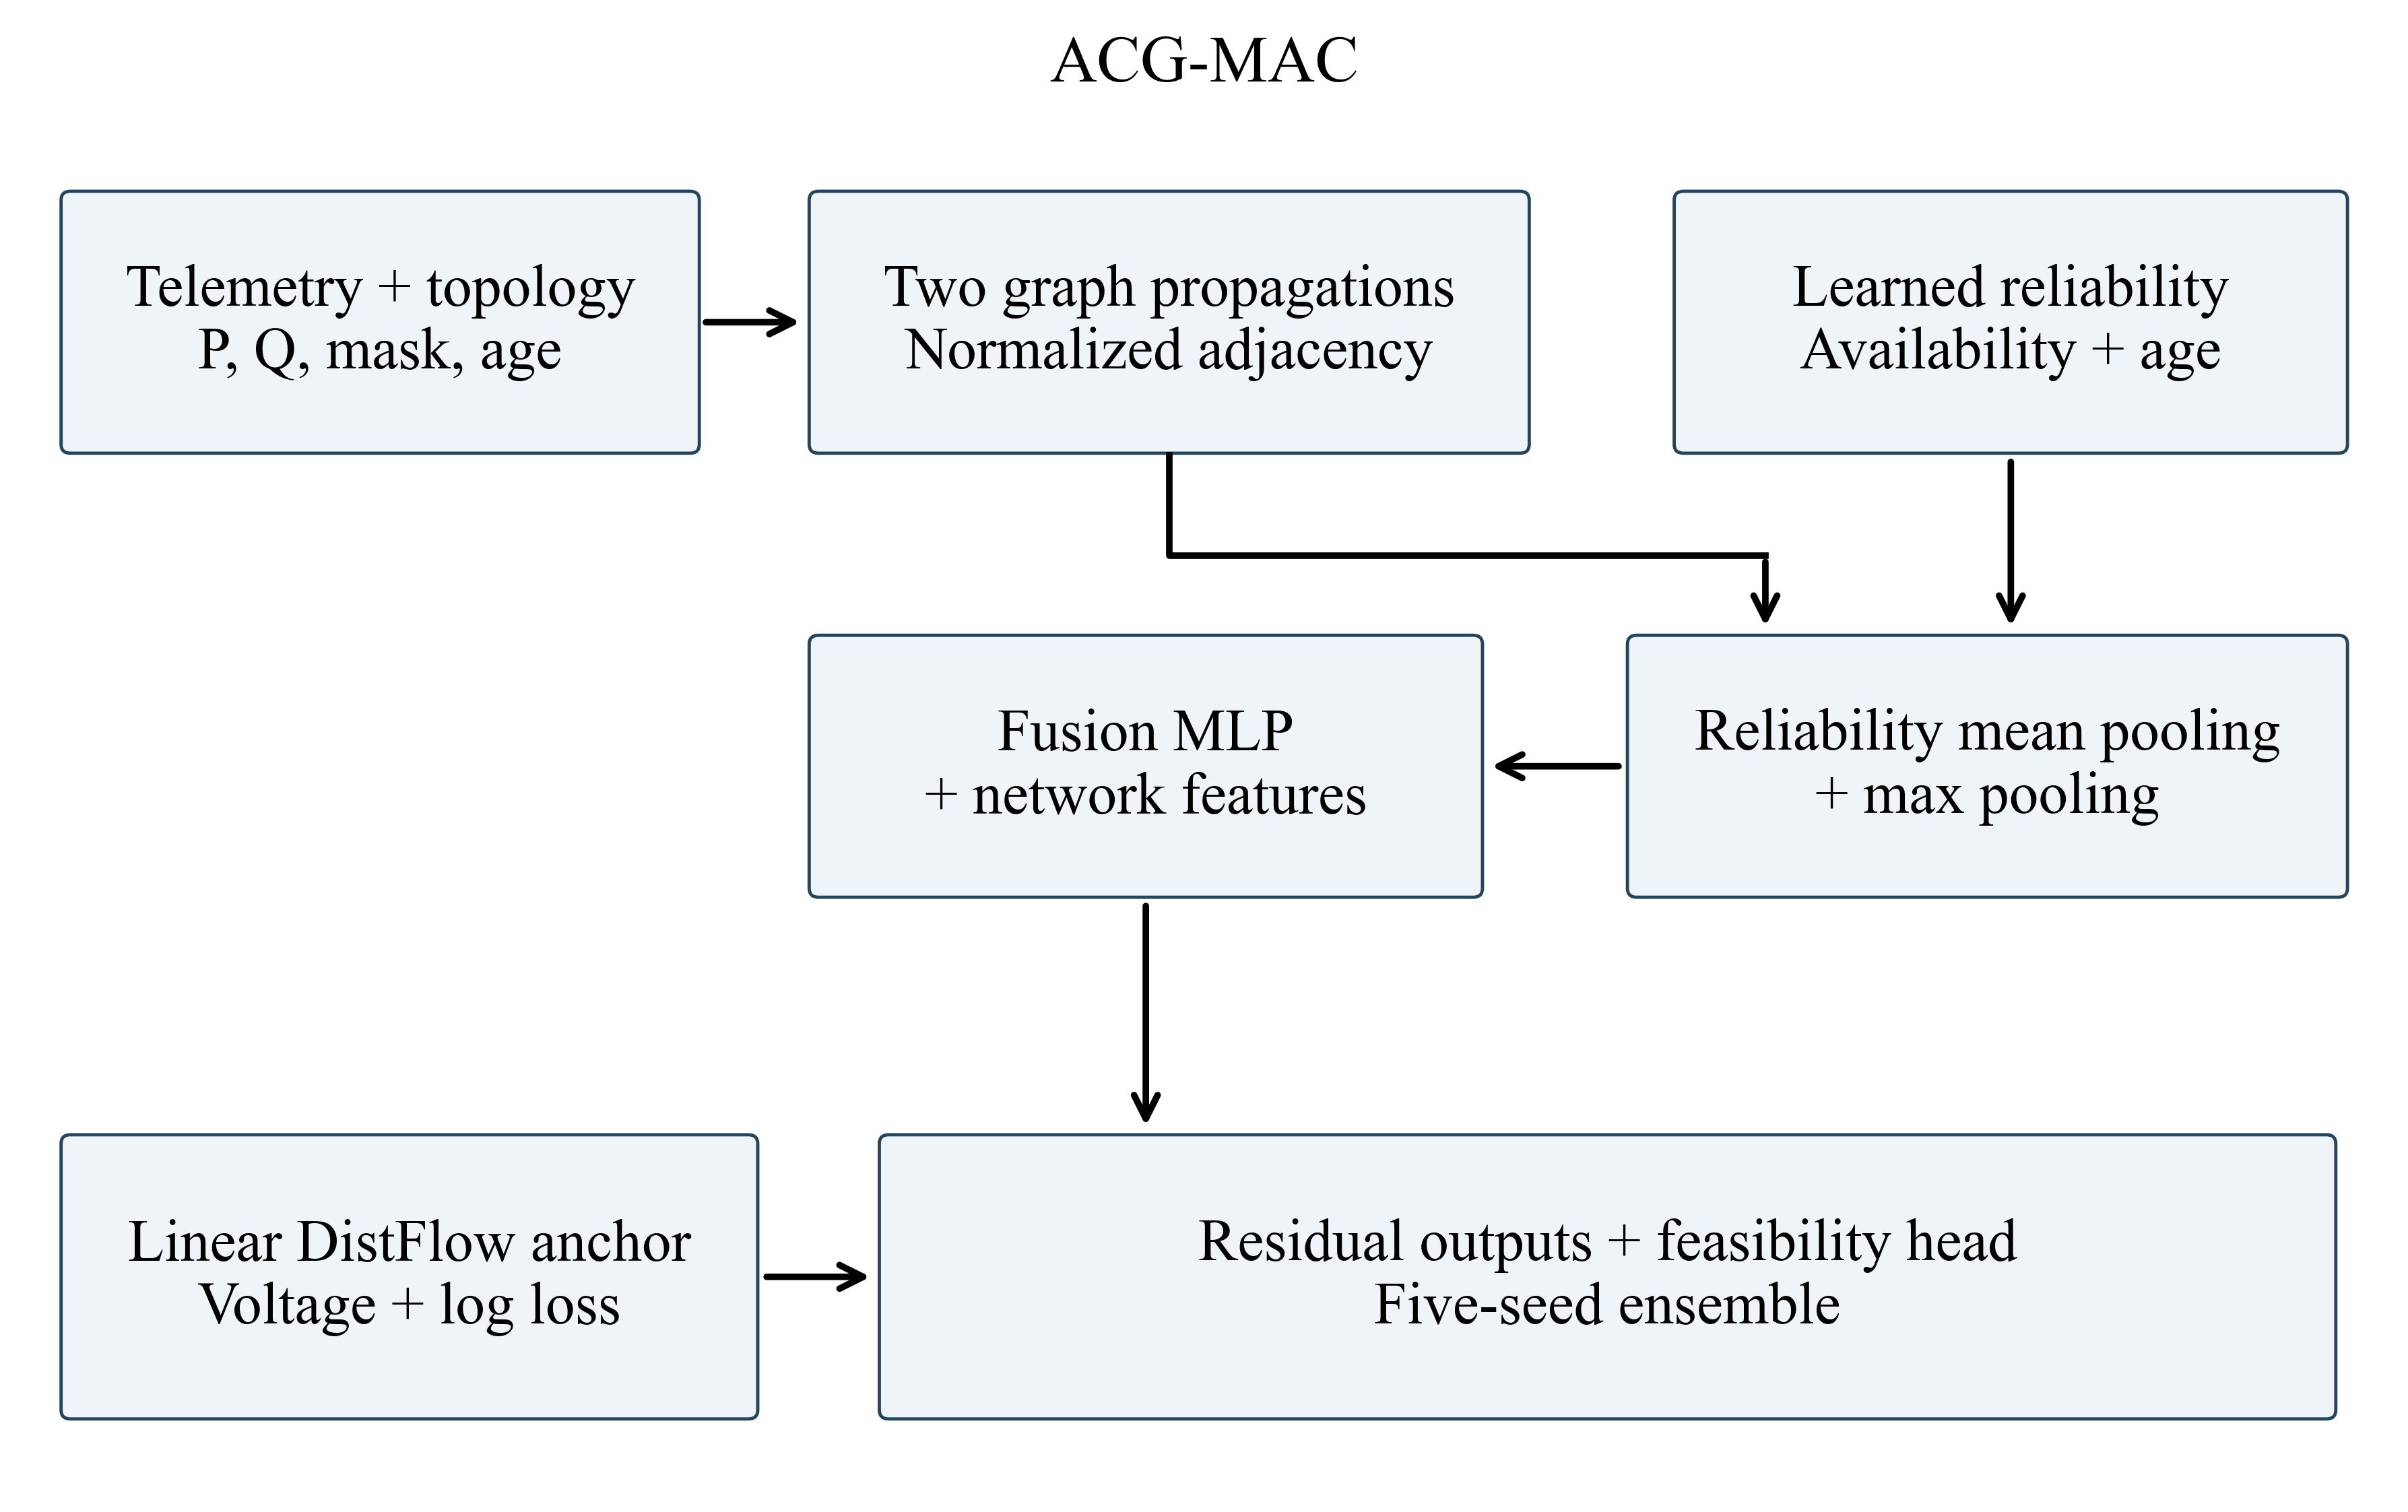

In [5]:
from matplotlib.patches import FancyBboxPatch

from matplotlib.patches import FancyBboxPatch

fig, axis = plt.subplots(figsize=(10.0, 6.2), layout="constrained")
axis.set(xlim=(0, 10), ylim=(0, 6.2))
axis.axis("off")
boxes = [
    (0.15, 4.65, 2.65, 1.1, "Telemetry + topology\nP, Q, mask, age"),
    (3.35, 4.65, 3.0, 1.1, "Two graph propagations\nNormalized adjacency"),
    (7.05, 4.65, 2.8, 1.1, "Learned reliability\nAvailability + age"),
    (6.85, 2.65, 3.0, 1.1, "Reliability mean pooling\n+ max pooling"),
    (3.35, 2.65, 2.8, 1.1, "Fusion MLP\n+ network features"),
    (0.15, 0.3, 2.9, 1.2, "Linear DistFlow anchor\nVoltage + log loss"),
    (3.65, 0.3, 6.15, 1.2, "Residual outputs + feasibility head\nFive-seed ensemble"),
]
for x, y, width, height, label in boxes:
    axis.add_patch(
        FancyBboxPatch(
            (x, y),
            width,
            height,
            boxstyle="round,pad=0.04",
            facecolor="#eef4f8",
            edgecolor="#24455c",
        )
    )
    axis.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=18)
for start, end in [
    ((2.84, 5.2), (3.3, 5.2)),
    ((8.45, 4.6), (8.45, 3.8)),
    ((6.8, 3.2), (6.2, 3.2)),
    ((4.75, 2.6), (4.75, 1.55)),
    ((3.1, 0.9), (3.6, 0.9)),
]:
    axis.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=2))
# The graph embedding and reliability weights enter the same pooling operation.
axis.plot([4.85, 4.85, 7.4], [4.6, 4.15, 4.15], color="black", linewidth=2)
axis.annotate("", xy=(7.4, 3.8), xytext=(7.4, 4.15), arrowprops=dict(arrowstyle="->", lw=2))
axis.set_title("ACG-MAC", fontsize=20)
save_figure(fig, FIGURES / "S5_ACG_MAC_computational_structure.png")
plt.show()

The physical anchor corrects outputs, while reliability affects mean pooling. The optional adaptive context gate remains inactive in the full configuration.

## Representation-width sensitivity

Hidden width is varied around the full configuration using selection-set error.

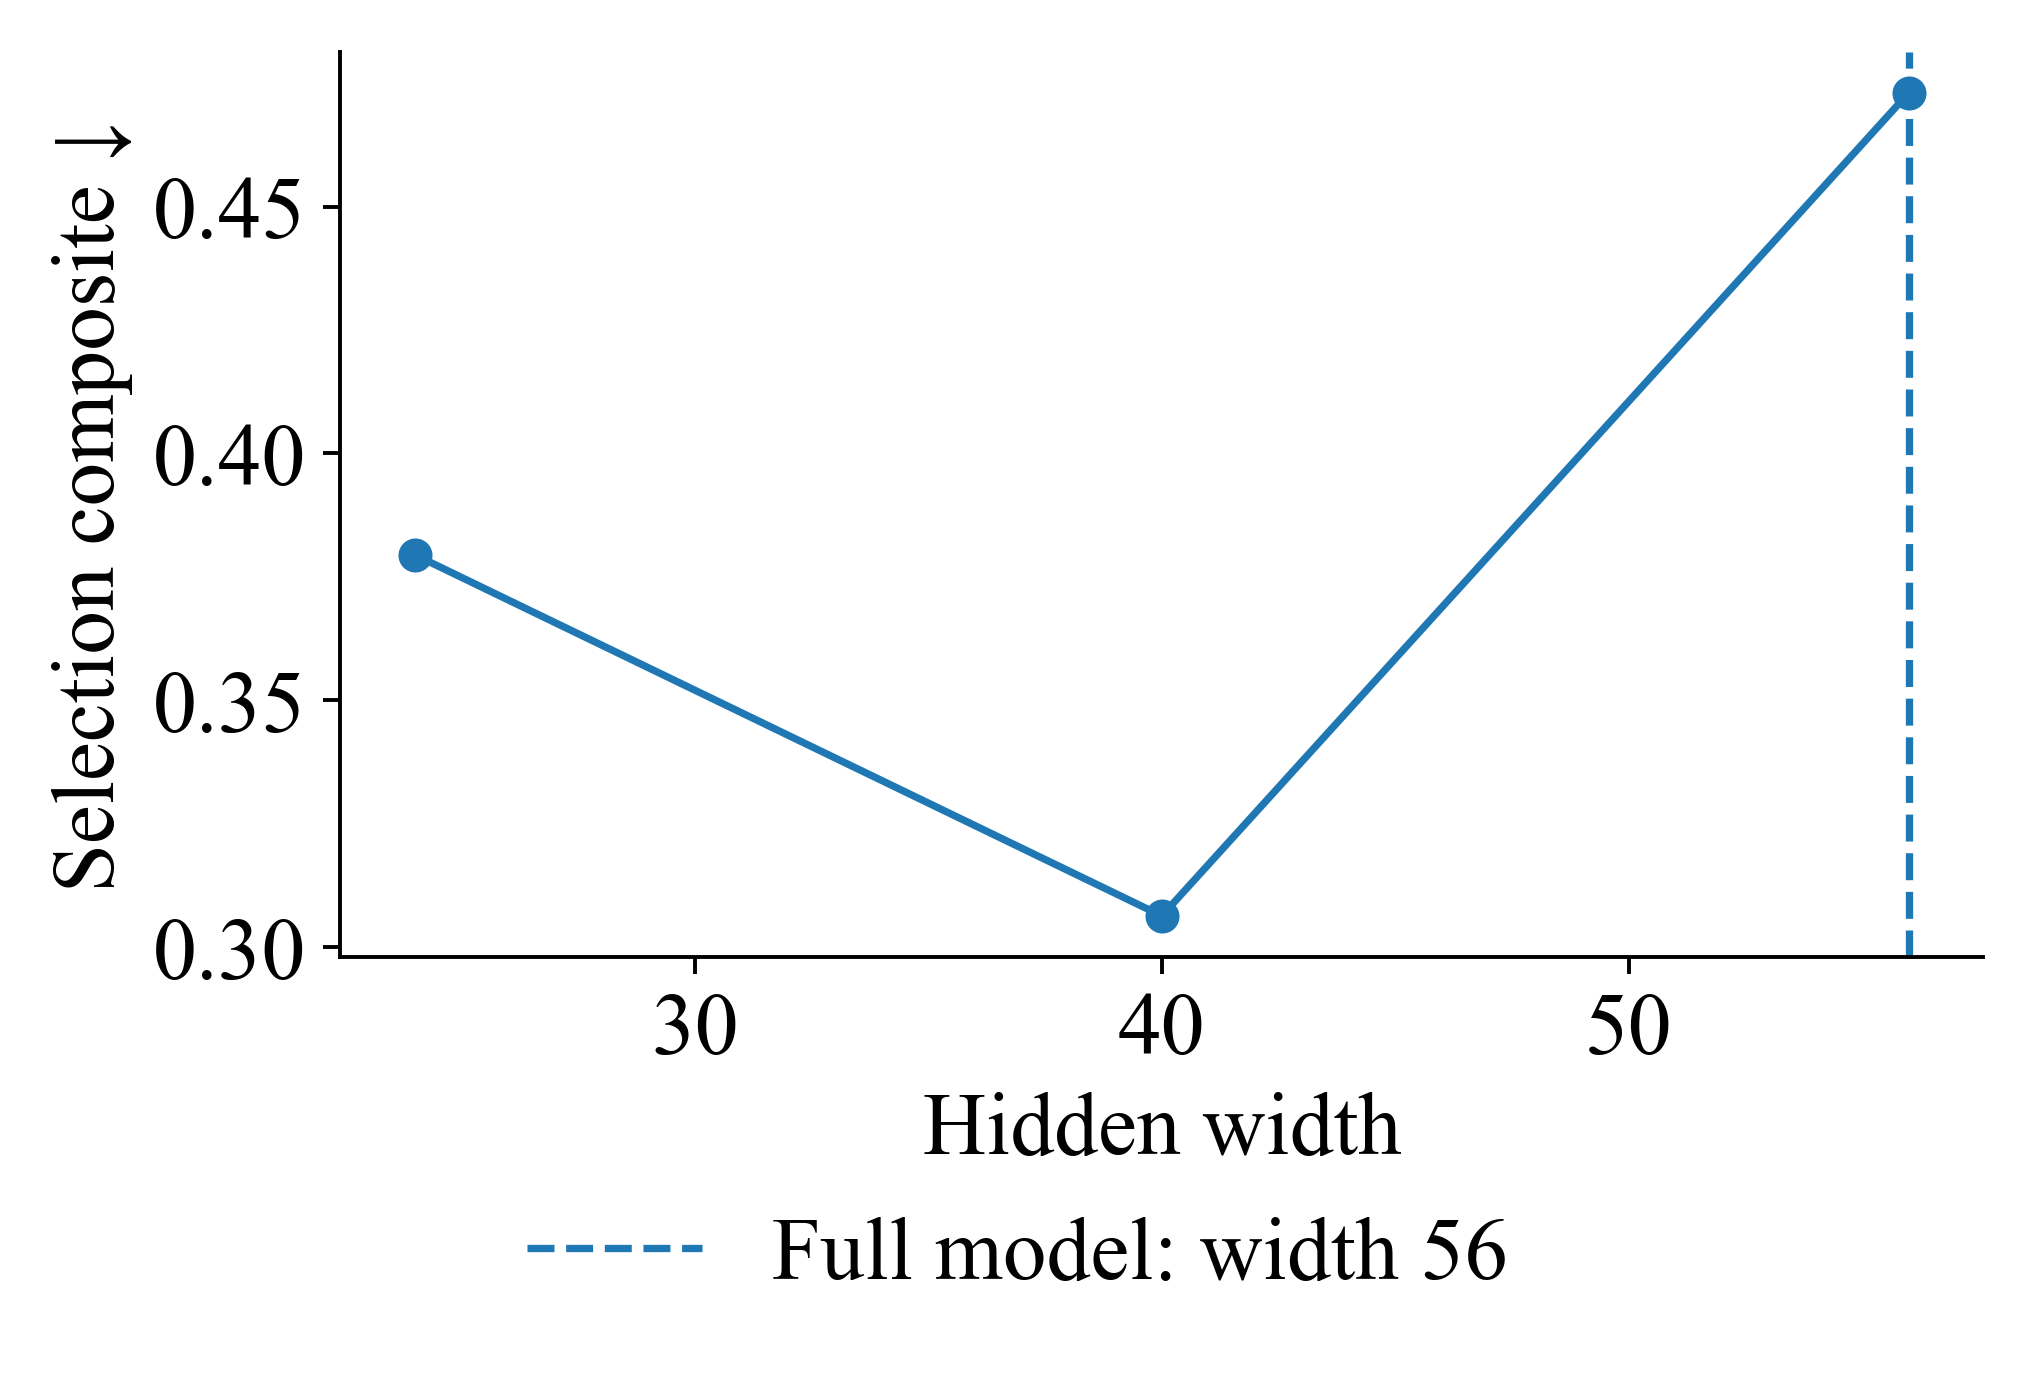

In [6]:
sensitivity_rows = []
for width in [24, 40, 56]:
    configuration = {**FULL_CONFIG, "hidden": width}
    trained = train_graph(
        bundle, indices["train"], indices["selection"], configuration, **TRAINING
    )
    prediction, _, _ = predict_graph_model(trained, bundle, indices["selection"])
    metrics = regression_metrics(bundle.targets[indices["selection"]], prediction)
    sensitivity_rows.append(
        dict(
            width=width,
            **metrics,
            composite=metrics["vmin_rmse"] / 0.02 + metrics["loss_rmse_kw"] / 60
        )
    )
sensitivity = pd.DataFrame(sensitivity_rows)
fig, axis = plt.subplots(figsize=(5.6, 3.8), layout="constrained")
axis.plot(sensitivity.width, sensitivity.composite, marker="o")
axis.axvline(56, linestyle="--", label="Full model: width 56")
axis.set(xlabel="Hidden width", ylabel="Selection composite ↓")
legend_handles, legend_labels = axis.get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=1, frameon=False)
save_figure(fig, FIGURES / "6_Hidden_width_sensitivity.png")
plt.show()
sensitivity.to_csv(TABLES / "05_sensitivity_source.csv", index=False)

Width 56 defines the full model. Alternative widths are selection-set sensitivity experiments; they do not determine a new configuration from test performance.

## Full configuration

The table records the architecture, objective and optimization settings.

In [7]:
configuration = pd.DataFrame(
    [
        dict(
            model="ACG-MAC Full",
            split="train / selection",
            n=len(indices["train"]),
            hidden_width=56,
            graph_layers=2,
            ensemble_members=5,
            maximum_epochs=TRAINING["epochs"],
            batch_size=TRAINING["batch_size"],
            learning_rate=TRAINING["learning_rate"],
            weight_decay=TRAINING["weight_decay"],
            auxiliary_weight=TRAINING["auxiliary_weight"],
            patience=TRAINING["patience"],
            adaptive_context_gate="inactive; original simple fusion",
        )
    ]
)
show_table(
    configuration,
    ["model", "split", "n"],
    {
        "Architecture": [
            "hidden_width",
            "graph_layers",
            "ensemble_members",
            "adaptive_context_gate",
        ],
        "Optimization": [
            "maximum_epochs",
            "batch_size",
            "learning_rate",
            "weight_decay",
            "auxiliary_weight",
            "patience",
        ],
    },
    TABLES / "05_configuration.csv",
    digits=6,
)

The maximum epoch budget and selection rule are common to graph controls and full model. The five-member ensemble has a larger total cost, which is explicitly reported.

## Five-seed training dynamics

Training and selection histories compare the five ensemble members.

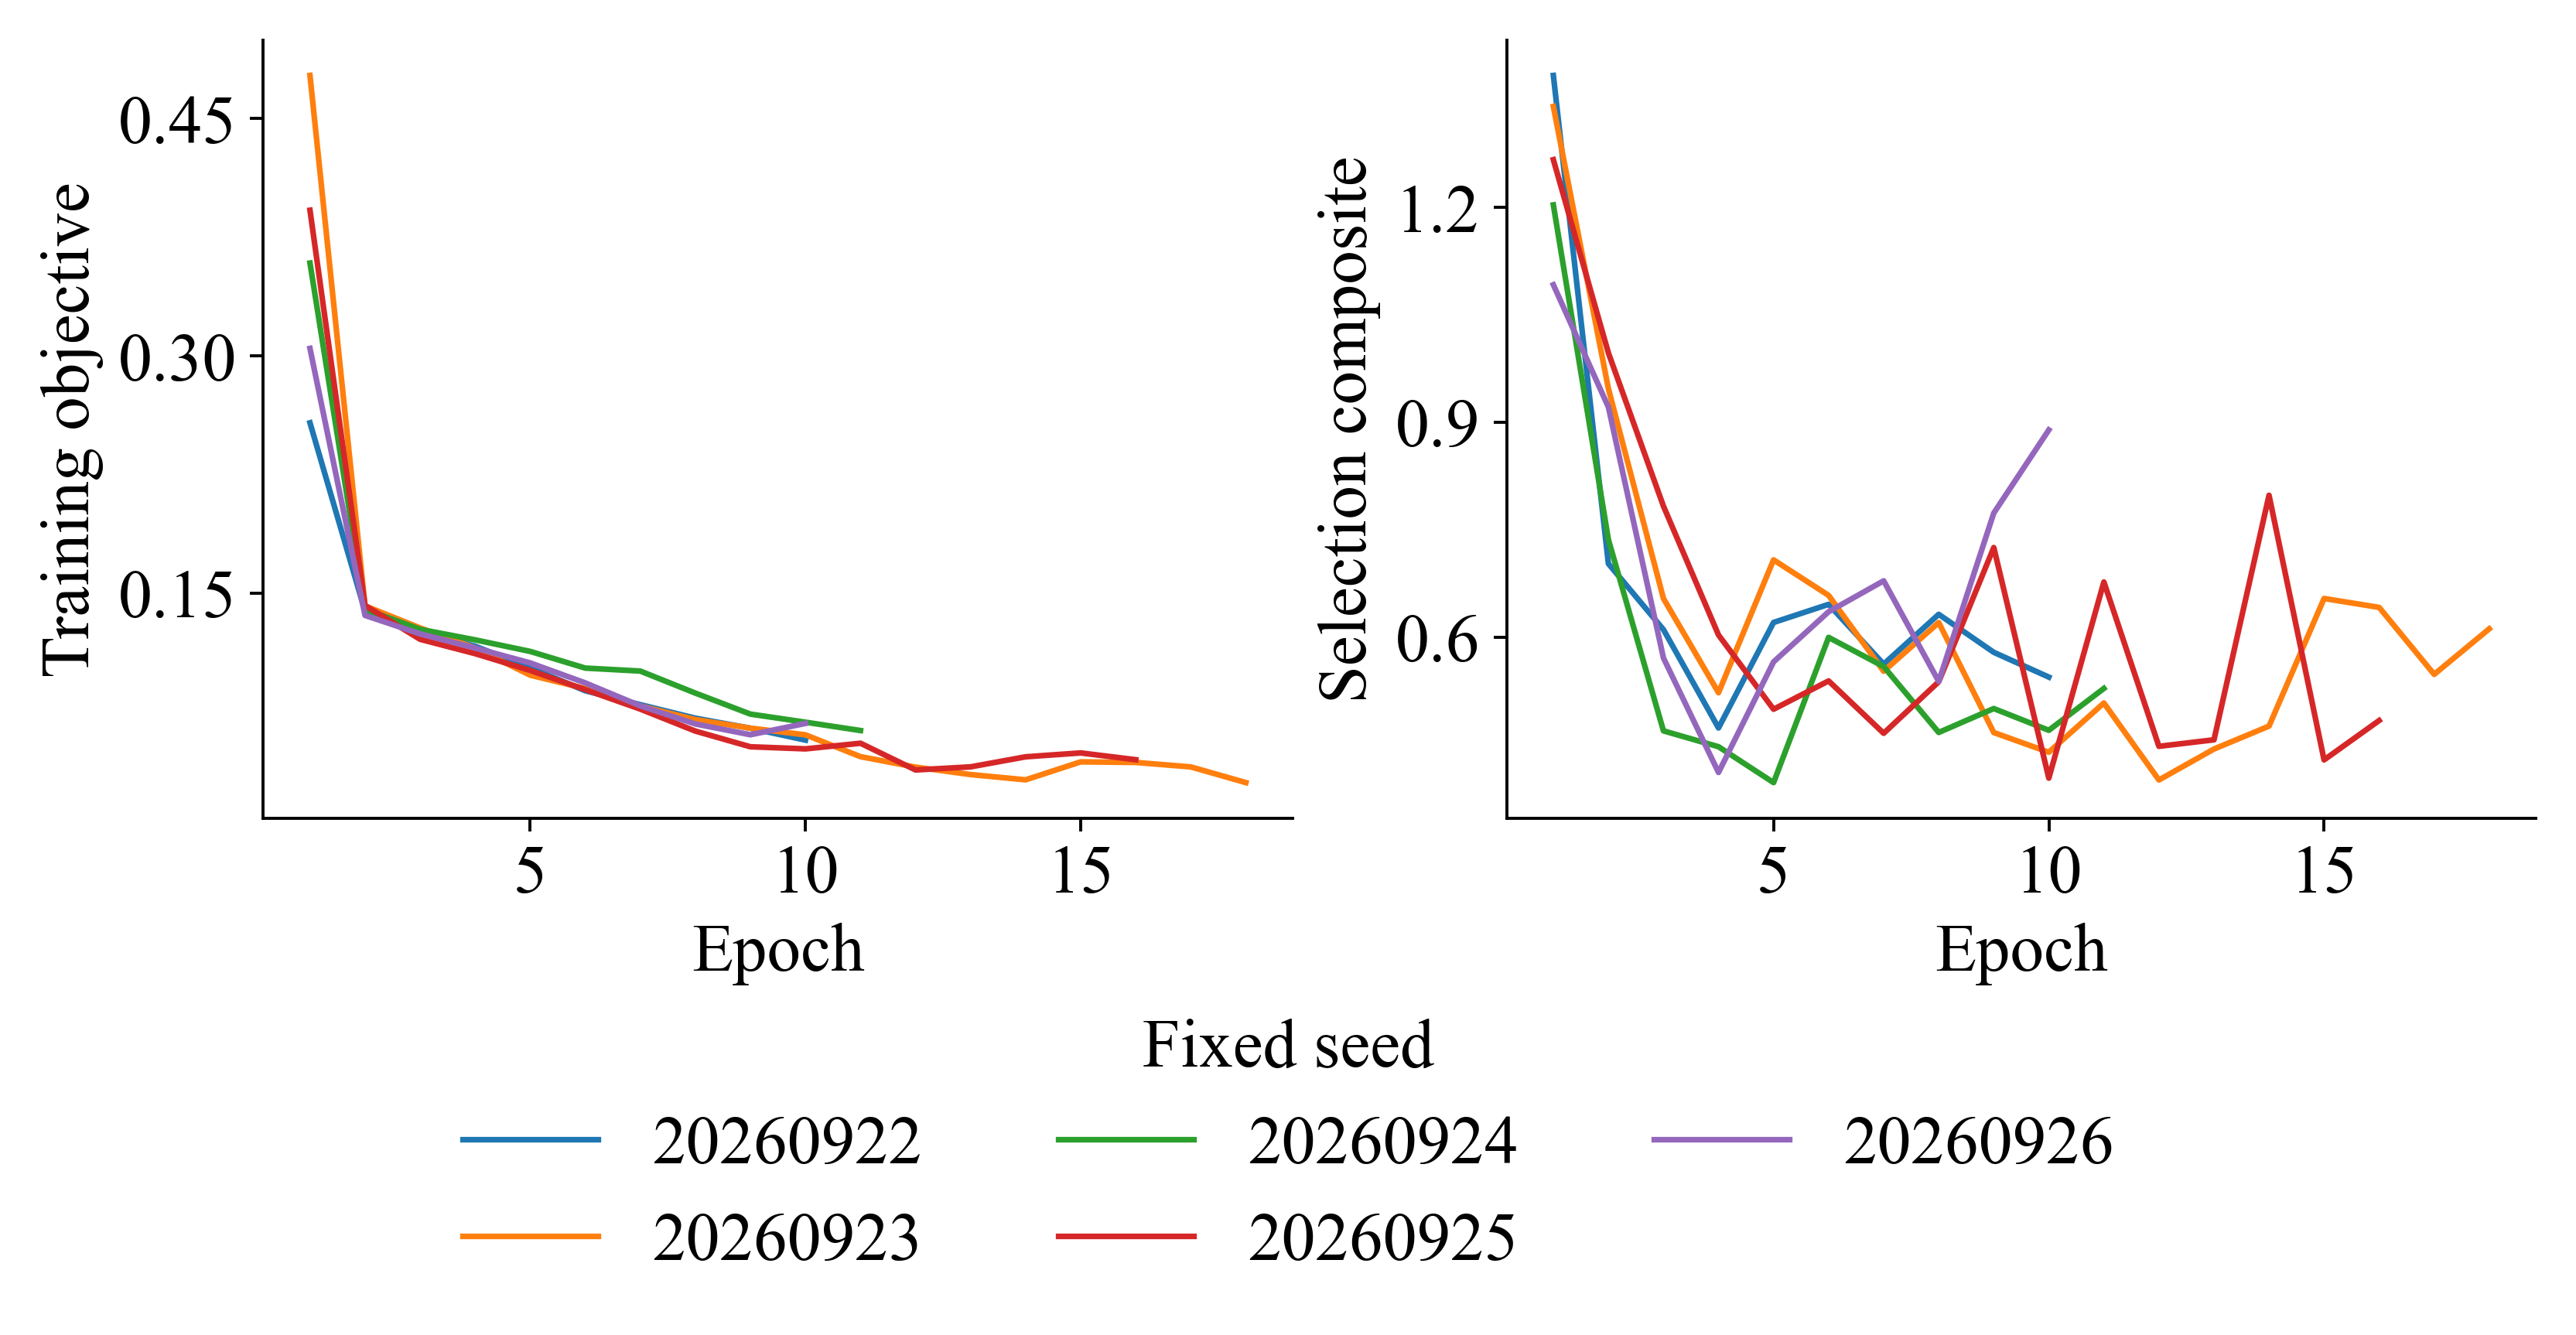

In [8]:
members, member_predictions, member_probabilities, histories, seed_rows = [], [], [], [], []
member_fit_times = []
with measure_resources() as ensemble_resources:
    for seed in SEEDS:
        fit_start = time.perf_counter()
        member = train_graph(
            bundle, indices["train"], indices["selection"], FULL_CONFIG, seed=seed, **TRAINING
        )
        member_fit_times.append(time.perf_counter() - fit_start)
        save_graph(member, MODELS / f"ACG_MAC_{seed}.pt", bundle)
        prediction, probability, _ = predict_graph_model(member, bundle, all_indices)
        members.append(member)
        member_predictions.append(prediction)
        member_probabilities.append(probability)
        histories.append(member.train_history.assign(seed=seed))
        seed_rows.append(
            dict(
                model="ACG-MAC Full",
                split="test converged",
                n=len(valid_test),
                seed=seed,
                **regression_metrics(bundle.targets[valid_test], prediction[valid_test]),
            )
        )
member_predictions = np.stack(member_predictions)
member_probabilities = np.stack(member_probabilities)
ensemble_prediction = member_predictions.mean(axis=0)
ensemble_probability = member_probabilities.mean(axis=0)
np.savez_compressed(
    prediction_path("ACG-MAC Ensemble"),
    sample_id=metadata.sample_id.to_numpy(),
    prediction=ensemble_prediction,
    probability=ensemble_probability,
    members=member_predictions,
    member_probabilities=member_probabilities,
)
pd.concat(histories).to_csv(RESULTS / "acg_history.csv", index=False)
pd.DataFrame(seed_rows).to_csv(RESULTS / "acg_seeds.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(9.3, 4.8), layout="constrained")
for history in histories:
    axes[0].plot(history.epoch, history.train_objective, label=str(int(history.seed.iloc[0])))
    axes[1].plot(history.epoch, history.selection_objective)
axes[0].set(xlabel="Epoch", ylabel="Training objective")
axes[1].set(xlabel="Epoch", ylabel="Selection composite")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    legend_handles,
    legend_labels,
    loc="outside lower center",
    ncol=3,
    frameon=False,
    title="Fixed seed",
)
from matplotlib.ticker import MaxNLocator

for panel in axes:
    panel.xaxis.set_major_locator(MaxNLocator(nbins=4))
    panel.yaxis.set_major_locator(MaxNLocator(nbins=4))
save_figure(fig, FIGURES / "7_Ensemble_training_dynamics.png")
plt.show()

The ensemble averages all five predetermined initializations. Learning curves show variability in optimization and selection performance across seeds.

## Full-model regression

Voltage and loss errors are evaluated for each data role.

In [9]:
regression_rows, probability_rows = [], []
for split in ["selection", "test", "external"]:
    selected = indices[split]
    valid = selected[metadata.iloc[selected].converged.to_numpy() == 1]
    regression_rows.append(
        dict(
            model="ACG-MAC Ensemble",
            split=split + " converged",
            n=len(valid),
            **regression_metrics(bundle.targets[valid], ensemble_prediction[valid]),
        )
    )
    probability_rows.append(
        dict(
            model="ACG-MAC Ensemble",
            split=split,
            n=len(selected),
            **probability_metrics(bundle.targets[selected, 2], ensemble_probability[selected]),
        )
    )
ensemble_regression = pd.DataFrame(regression_rows)
pd.DataFrame(probability_rows).to_csv(RESULTS / "acg_probability.csv", index=False)
ensemble_regression.to_csv(RESULTS / "acg_regression.csv", index=False)
show_table(
    ensemble_regression,
    ["model", "split", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "05_ensemble_regression.csv",
    digits=6,
)
test_row = ensemble_regression[ensemble_regression.split.eq("test converged")].iloc[0]

model,split,n,vmin_rmse,vmin_mae,vmin_r2
ACG-MAC Ensemble,selection converged,638,0.002679,0.001379,0.997961
ACG-MAC Ensemble,test converged,605,0.006698,0.002405,0.992514
ACG-MAC Ensemble,external converged,800,0.440555,0.440403,−286.074139
model,split,n,loss_rmse_kw,loss_mae_kw,loss_r2
ACG-MAC Ensemble,selection converged,638,13.564413,5.321213,0.992082
ACG-MAC Ensemble,test converged,605,48.771030,12.559648,0.964351
ACG-MAC Ensemble,external converged,800,1.116969e+06,954378.535452,−2.264270e+08


Regression errors are reported separately for selection, test and external states. Different target scales require separate voltage and active-loss metrics.

## Ensemble out-of-fold evaluation

Each OOF ensemble excludes its held topology group from fitting and early stopping.

In [10]:
training = indices["train"]
oof_prediction = np.full((len(training), 2), np.nan)
oof_probability = np.full(len(training), np.nan)
oof_rows = []
for fold in range(3):
    fold_training = training[fold_id[training] != fold]
    held = training[fold_id[training] == fold]
    fit, select = inner_group_selection(bundle, fold_training, SEED + fold)
    predictions, probabilities = [], []
    for seed in SEEDS:
        member = train_graph(bundle, fit, select, FULL_CONFIG, seed=seed, **TRAINING)
        prediction, probability, _ = predict_graph_model(member, bundle, held)
        predictions.append(prediction)
        probabilities.append(probability)
    prediction, probability = np.mean(predictions, axis=0), np.mean(probabilities, axis=0)
    positions = np.flatnonzero(fold_id[training] == fold)
    oof_prediction[positions], oof_probability[positions] = prediction, probability
    oof_rows.append(
        dict(
            model="ACG-MAC Ensemble",
            split="training OOF",
            fold=fold,
            n=len(held),
            **regression_metrics(bundle.targets[held], prediction)
        )
    )
assert np.isfinite(oof_prediction).all()
np.savez_compressed(
    RESULTS / "ACG-MAC_Ensemble_oof.npz",
    sample_id=metadata.sample_id.to_numpy()[training],
    fold=fold_id[training],
    prediction=oof_prediction,
    probability=oof_probability,
)
oof = pd.DataFrame(oof_rows)
oof.to_csv(RESULTS / "acg_oof.csv", index=False)
show_table(
    oof,
    ["model", "split", "fold", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "05_oof.csv",
    digits=6,
)

model,split,fold,n,vmin_rmse,vmin_mae,vmin_r2
ACG-MAC Ensemble,training OOF,0,715,0.002772,0.001761,0.997819
ACG-MAC Ensemble,training OOF,1,714,0.002098,0.001436,0.998183
ACG-MAC Ensemble,training OOF,2,717,0.003214,0.002018,0.997897
model,split,fold,n,loss_rmse_kw,loss_mae_kw,loss_r2
ACG-MAC Ensemble,training OOF,0,715,9.110922,4.381895,0.994924
ACG-MAC Ensemble,training OOF,1,714,9.419446,4.082161,0.992632
ACG-MAC Ensemble,training OOF,2,717,18.598620,8.505958,0.989936


Every OOF ensemble is trained anew without its held topology group. The same observation order as baseline OOF predictions permits paired comparison.

## Mechanism and objective ablations

Matched seeds compare individual components, objectives, regularization and model capacity.

In [11]:
variants = {
    "Full single member": (FULL_CONFIG, {}),
    "No learned reliability": ({**FULL_CONFIG, "use_reliability": False}, {}),
    "No physics residual": ({**FULL_CONFIG, "use_physics_residual": False}, {}),
    "No graph propagation": ({**FULL_CONFIG, "use_graph": False}, {}),
    "No auxiliary loss": ({**FULL_CONFIG, "use_multitask": False}, {"auxiliary_weight": 0.0}),
    "Adaptive context gate control": ({**FULL_CONFIG, "simple_fusion": False}, {}),
    "No scaled regression loss": (FULL_CONFIG, {"scale_voltage": 1.0, "scale_log_loss": 1.0}),
    "No dropout or weight decay": (FULL_CONFIG, {"weight_decay": 0.0, "disable_dropout": True}),
    "Parameter-matched node MLP": (
        {**FULL_CONFIG, "use_graph": False, "use_reliability": False},
        {},
    ),
}
ablation_rows = []
for name, (configuration, overrides) in variants.items():
    for seed in SEEDS[:3]:
        member = (
            members[list(SEEDS).index(seed)]
            if name == "Full single member"
            else train_graph(
                bundle,
                indices["train"],
                indices["selection"],
                configuration,
                seed=seed,
                **{**TRAINING, **overrides}
            )
        )
        prediction, _, _ = predict_graph_model(member, bundle, valid_test)
        ablation_rows.append(
            dict(
                model=name,
                split="test converged",
                n=len(valid_test),
                seed=seed,
                parameters=sum(parameter.numel() for parameter in member.model.parameters()),
                **regression_metrics(bundle.targets[valid_test], prediction)
            )
        )
physical_prediction, _ = load_predictions("LinearDistFlow")
ablation_rows.append(
    dict(
        model="Physical component only",
        split="test converged",
        n=len(valid_test),
        seed=SEED,
        parameters=0,
        **regression_metrics(bundle.targets[valid_test], physical_prediction[valid_test])
    )
)
ablation = pd.DataFrame(ablation_rows)
ablation.to_csv(RESULTS / "ablations.csv", index=False)
summary = (
    ablation.groupby(["model", "split", "n"], sort=False)
    .agg(
        seeds=("seed", "nunique"),
        parameters=("parameters", "first"),
        vmin_rmse_mean=("vmin_rmse", "mean"),
        vmin_rmse_sd=("vmin_rmse", "std"),
        loss_rmse_mean_kw=("loss_rmse_kw", "mean"),
        loss_rmse_sd_kw=("loss_rmse_kw", "std"),
    )
    .reset_index()
)
show_table(
    summary,
    ["model", "split", "n"],
    {
        "Voltage across seeds ↓": ["vmin_rmse_mean", "vmin_rmse_sd"],
        "Loss across seeds ↓": ["loss_rmse_mean_kw", "loss_rmse_sd_kw"],
        "Controlled capacity": ["seeds", "parameters"],
    },
    TABLES / "05_ablations.csv",
    digits=6,
)

model,split,n,vmin_rmse_mean,vmin_rmse_sd
Full single member,test converged,605,0.007498,0.001140
No learned reliability,test converged,605,0.007071,0.001295
No physics residual,test converged,605,0.022449,0.004563
No graph propagation,test converged,605,0.007794,0.000925
No auxiliary loss,test converged,605,0.005291,0.000550
Adaptive context gate control,test converged,605,0.007488,0.002422
No scaled regression loss,test converged,605,0.013250,0.005734
No dropout or weight decay,test converged,605,0.006945,0.000868
Parameter-matched node MLP,test converged,605,0.007642,0.001322
Physical component only,test converged,605,0.020858,Not applicable


The full model uses simple fusion; the adaptive context gate is a separate control. Linear DistFlow isolates the physical component. Parameter counts include allocated inactive modules, so the node-MLP control matches stored capacity rather than exactly matching active coefficients. The deterministic physical component has no seed variability.

## Internal reliability behavior

Node pooling weights are grouped by measurement availability and telemetry age.

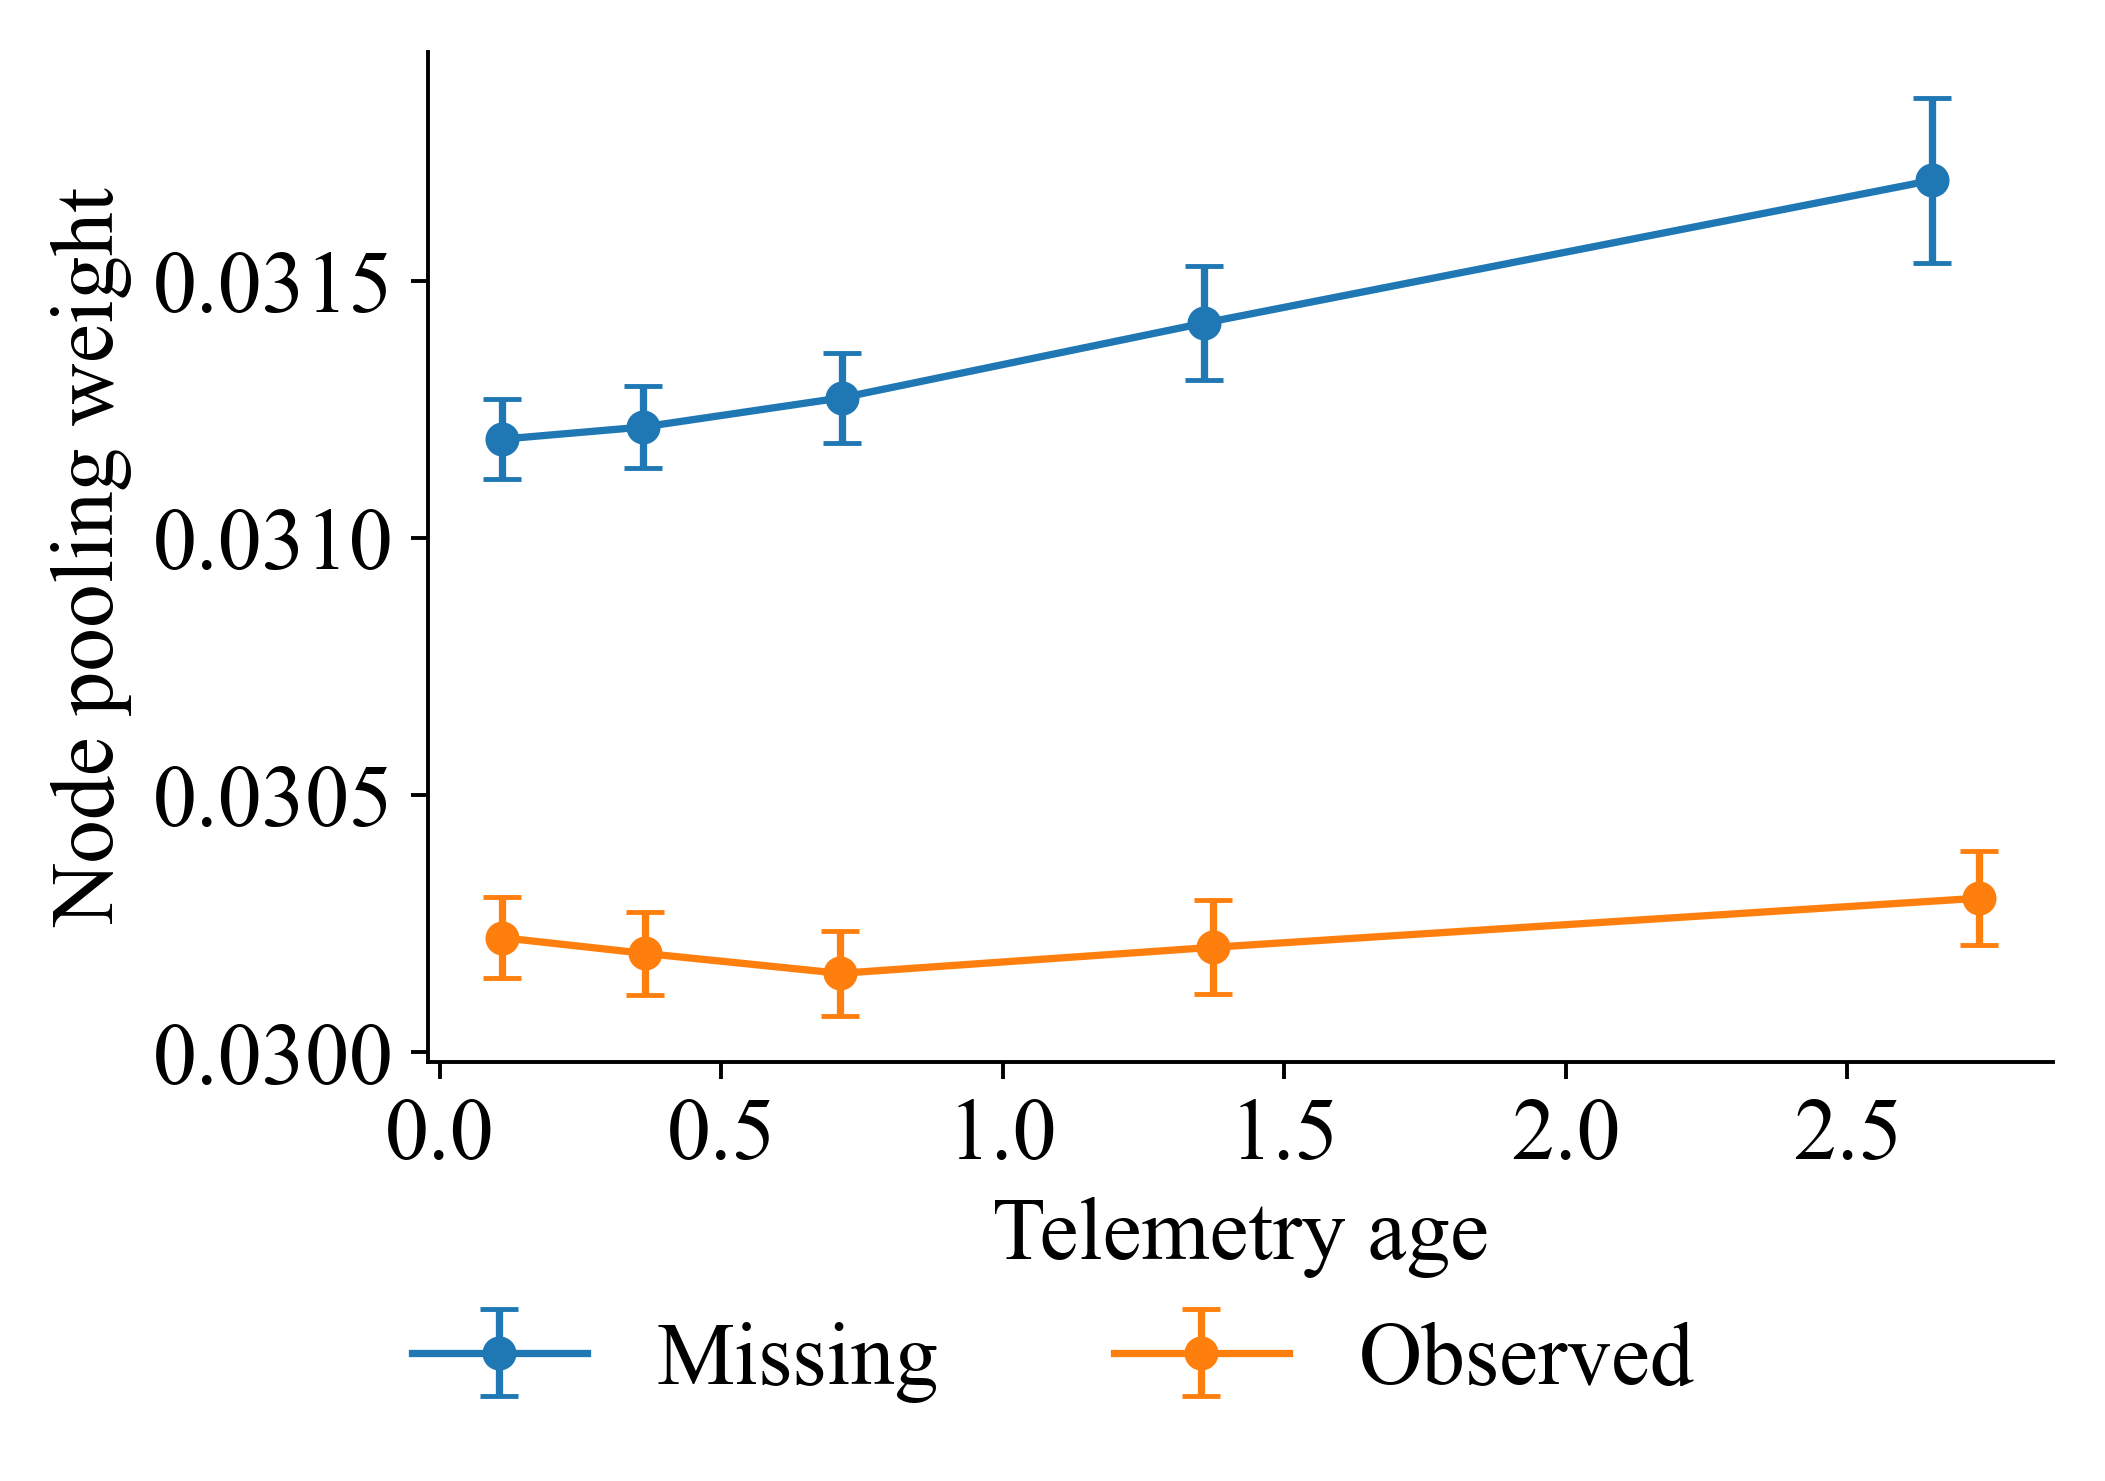

In [12]:
_, _, weights = predict_graph_model(members[0], bundle, indices["test"])
node = bundle.node_features[indices["test"], :33]
frame = pd.DataFrame(
    dict(
        age=node[:, :, 7].ravel() * 4,
        observed=node[:, :, 6].ravel(),
        weight=weights[:, :33].ravel(),
    )
)
frame["age_bin"] = pd.cut(frame.age, bins=[0, 0.25, 0.5, 1, 2, 4], include_lowest=True)
grouped = (
    frame.groupby(["observed", "age_bin"], observed=True)
    .agg(
        mean_age=("age", "mean"),
        weight_mean=("weight", "mean"),
        weight_sd=("weight", "std"),
        n=("weight", "size"),
    )
    .reset_index()
)
fig, axis = plt.subplots(figsize=(5.8, 4.1), layout="constrained")
for observed, group in grouped.groupby("observed"):
    axis.errorbar(
        group.mean_age,
        group.weight_mean,
        yerr=group.weight_sd,
        marker="o",
        capsize=4,
        label="Observed" if observed else "Missing",
    )
axis.set(xlabel="Telemetry age", ylabel="Node pooling weight")
legend_handles, legend_labels = axis.get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
save_figure(fig, FIGURES / "8_Node_pooling_weights.png")
plt.show()
grouped.to_csv(TABLES / "05_reliability_source.csv", index=False)

Bars represent within-bin standard deviation, not independent-observation confidence intervals. Internal weights are descriptive and do not establish causal effects or robust control.

In [13]:
timings = []
for repeat in range(6):
    start = time.perf_counter()
    for member in members:
        predict_graph_model(member, bundle, indices["test"])
    if repeat:
        timings.append((time.perf_counter() - start) * 1000 / len(indices["test"]))
efficiency = pd.DataFrame(
    [
        dict(
            model="ACG-MAC Ensemble",
            split="test",
            n=len(indices["test"]),
            train_time_s=sum(member_fit_times),
            inference_ms=float(np.median(timings)),
            inference_iqr_ms=float(np.subtract(*np.percentile(timings, [75, 25]))),
            peak_process_rss_mib=ensemble_resources.peak_rss_mib,
            added_rss_mib=ensemble_resources.incremental_rss_mib,
            serialized_mib=sum((MODELS / f"ACG_MAC_{seed}.pt").stat().st_size for seed in SEEDS)
            / 2**20,
            trainable_parameters=sum(
                parameter.numel()
                for member in members
                for parameter in member.model.parameters()
            ),
        )
    ]
)
efficiency.to_csv(RESULTS / "acg_efficiency.csv", index=False)

## Component behavior

Removing the auxiliary classification loss improves voltage and loss RMSE in the matched-seed runs, indicating a trade-off between objectives. The physical residual contributes the clearest regression benefit among these controls. Pooling weights remain close to uniform and are slightly higher for missing nodes in the displayed member; they should not be interpreted as calibrated reliability probabilities or a monotone penalty for telemetry age.